In [10]:
import importlib
import matplotlib.pyplot as plt
import numpy as np
import warnings
import pickle

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

import globals
import utils
import nn_dataset
import nn_models

np.set_printoptions(precision=4, suppress=True, linewidth=np.inf, threshold=np.inf)

In [2]:
importlib.reload(globals)
importlib.reload(utils)
importlib.reload(nn_dataset)
importlib.reload(nn_models)

<module 'nn_models' from 'c:\\Users\\Matteo\\Desktop\\Scuola\\MastersThesis\\Masters_Thesis\\nn_models.py'>

In [3]:
param_names, function_names = utils.inspect_metadata(globals.CURRENT_TRAIN_FILE)

Keys in train_file: ['I0', 'LUTdata', 'LUTheader', 'dynamic', 'static', 'wvl']

Attributes in LUTheader (inputs):
  varnames: O3STR,H2OSTR,VIS,G,ASTMX,SSA,PARM2,OBSZEN,PARM1

Attributes in train_file (outputs):
  RTMname: MODTRAN6
  inputmode: Latin hypercube
  lut_package_date: 10-Apr-2025
  opmode: Transfer Functions
  outnames: Lp0,Edir0,Edif0,S,tdir,tdif
  sensor: Empty(dtype=dtype('O'))

LUTheader shape: (500, 9)
LUTdata shape: (500, 25230)
wvl shape: (1, 4205)


In [4]:
X, Y, wavelengths = utils.load_train_h5(globals.CURRENT_TRAIN_FILE)
wavelengths = wavelengths.squeeze()
Y_resh = Y.reshape(-1, Y.shape[1] // len(wavelengths), len(wavelengths))

#### Features Definition and Selection

The code below is a Python port of a MATLAB feature-selection / SIC-method code.

Original MATLAB methods by the author Dr. Luca Martino (Universidad Rey Juan Carlos):
<ul>
    <li>Feature Selection: greedy forward feature ranking based on a 2nd degree polynomial-fit emulator's prediction error.</li>
    <li>SIC Method: Spectral Information Criterion (elbow method) used to automatically decide how many of the ranked features to keep.</li>
</ul>

Indexing note: everything below has been converted from MATLAB's 1-based indexing to Python's 0-based indexing. Selected feature indices returned by `feature_selection` are therefore 0-based column indices into `Xt`.

In [5]:
def build_physics_features(X, eps=1e-8):
    """
    Expand RT atmospheric inputs with physics-informed features.

    Input columns:
        0: O3
        1: CWV
        2: AOD
        3: Asy. Param. (g)
        4: Ang. Exp. (AE)
        5: SSA
        6: SZA
        7: VZA
        8: RAA

    Returns:
        X_expanded, feature_names
    """

    # unpack
    O3  = X[:, 0]
    CWV = X[:, 1]
    AOD = X[:, 2]
    g   = X[:, 3]
    AE  = X[:, 4]
    SSA = X[:, 5]
    SZA = X[:, 6]
    VZA = X[:, 7]
    RAA = X[:, 8]

    # radians
    sza = np.deg2rad(SZA)
    vza = np.deg2rad(VZA)
    raa = np.deg2rad(RAA)

    # geometric path length
    mu_s = np.cos(sza)
    mu_v = np.cos(vza)
    sec_sza = 1.0 / (mu_s + eps)
    sec_vza = 1.0 / (mu_v + eps)
    airmass = sec_sza + sec_vza


    # gas absorption path features
    CWV_airmass = CWV * airmass
    log_CWV = np.log(CWV + eps)
    O3_airmass = O3 * airmass
    log_O3 = np.log(O3 + eps)
    CWV_sec_sza = CWV * sec_sza


    # aerosol optical features
    log_AOD = np.log(AOD + eps)
    AOD_sec_sza = AOD * sec_sza
    AOD_airmass = AOD * airmass
    AE_squared = AE**2
    AOD_AE = AOD * AE


    # aerosol absorption/scattering
    absorption_fraction = 1 - SSA
    aerosol_absorption_OD = (1 - SSA) * AOD
    aerosol_scattering_OD = SSA * AOD
    g_squared = g**2
    SSA_g = SSA * g
    g_AOD = g * AOD


    # backscatter fraction
    Ba_g = (
        (1 - g) / (2 * g + eps)
        *
        (
            (1 + g) / np.sqrt(1 + g**2 + eps)
            - 1
        )
    )


    # scattering geometry
    cos_theta = (
        -np.cos(sza) * np.cos(vza)
        + np.cos(raa) * np.sin(sza) * np.sin(vza)
    )
    mu = np.cos(np.deg2rad(SZA)) * np.cos(np.deg2rad(VZA))


    # assemble
    features = [
        # original variables
        O3,
        CWV,
        AOD,
        g,
        AE,
        SSA,
        SZA,
        VZA,
        RAA,

        # geometry
        mu_s,
        sec_sza,
        mu_v,
        sec_vza,
        airmass,

        # gases
        CWV_airmass,
        log_CWV,
        O3_airmass,
        log_O3,
        CWV_sec_sza,

        # aerosols
        log_AOD,
        AOD_sec_sza,
        AOD_airmass,
        AE_squared,
        AOD_AE,

        # scattering properties
        absorption_fraction,
        aerosol_absorption_OD,
        aerosol_scattering_OD,
        g_squared,
        SSA_g,
        g_AOD,
        Ba_g,

        # phase geometry
        cos_theta,
        mu,
    ]


    feature_names = [
        "O3",
        "CWV",
        "AOD",
        "g",
        "AE",
        "SSA",
        "SZA",
        "VZA",
        "RAA",

        "cos_SZA",
        "sec_SZA",
        "cos_VZA",
        "sec_VZA",
        "airmass",

        "CWV_airmass",
        "log_CWV",
        "O3_airmass",
        "log_O3",
        "CWV_sec_SZA",

        "log_AOD",
        "AOD_sec_SZA",
        "AOD_airmass",
        "AE_squared",
        "AOD_AE",

        "1_minus_SSA",
        "AOD_absorption_OD",
        "AOD_scattering_OD",
        "g_squared",
        "SSA_g",
        "g_AOD",
        "Ba_g",

        "cos_scattering_angle",
        "mu",
    ]


    X_expanded = np.column_stack(features)
    return X_expanded, feature_names

X_expanded, feature_names = build_physics_features(X)
print(f"X expanded shape: {X_expanded.shape}\n")

X_tr_expanded, X_val_expanded, X_test_expanded, Y_tr, Y_val, Y_test = utils.train_val_test_split(X_expanded, Y_resh, wavelengths, verbose=True)

X expanded shape: (500, 33)

X shape: (500, 33)
Y shape: (500, 6, 4205)
wavelengths shape: (4205,)

X_tr shape: (400, 33)
X_val shape: (50, 33)
X_test shape: (50, 33)

Y_tr shape: (400, 6, 4205)
Y_val shape: (50, 6, 4205)
Y_test shape: (50, 6, 4205)


Error at SIC selection: 0.24643781016424043


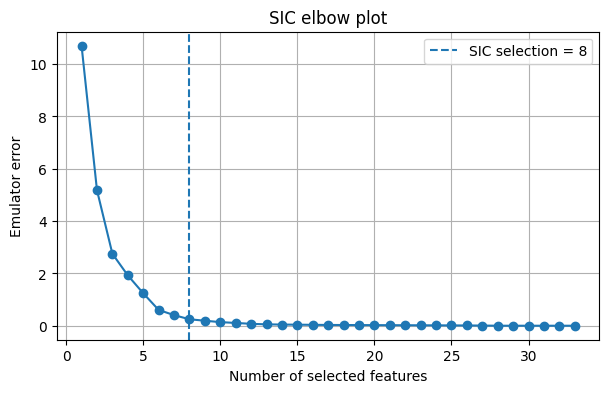

Selected (0-based) feature indices: [ 4  9 16 18 19 20 26 28]
Sensitivities: [0.0105 0.003  0.0009 0.0036 0.0007 0.9536 0.0239 0.0028]


In [7]:
class FeatureSelectionEmulator:
    """
    Minimal container mirroring the MATLAB `obj` that featureSelection and
    SICmethod were methods of (obj.conf.kernel, obj.SICmethod(...)).
    """

    def __init__(self, kernel='none', interp_func=None):
        """
        kernel : str
            Equivalent to `obj.conf.kernel`. If this equals 'mahalanobissquaredexponential', the SIC elbow-detection step
            is skipped and *all* ranked features are kept (matching the MATLAB `if ~strcmp(...)` branch).
        interp_func : callable
            The emulator/interpolation function.
        """
        self.conf = {'kernel': kernel}
        self.interp_func = interp_func

    # ------------------------------------------------------------------
    def feature_selection(self, Xt, Yt, alpha=1.0, plotting=False):
        """
        Ranks the input variables by importance based on the accuracy of
        a polynomial fitting, recursively adding more input variables.
        Once ranked, the Spectral Information Criterion (SIC) method is
        applied to automatically select the minimum number of features.

        Xt : ndarray, shape (n_samples, n_features)
            Training inputs (each column is a candidate feature).
        Yt : ndarray, shape (n_samples, n_outputs)
            Training targets (e.g. samples of a transfer function).
        alpha : float, optional
            Exponent used in the error metric |Yt - out|**alpha.
            Default 1 (L1 norm), matching the MATLAB code.

        Returns
        -------
        features : ndarray of int
            0-based indices of the selected features, sorted ascending.
        w : ndarray of float
            Normalized sensitivity ("importance") of each selected feature, in the same order as `features`.
        """
        warnings.filterwarnings('ignore')

        Xt = np.asarray(Xt)
        Yt = np.asarray(Yt, dtype=float)
        if Yt.ndim == 1:
            Yt = Yt.reshape(-1, 1)

        n_samples, n_features = Xt.shape

        ii = list(range(n_features))        # remaining candidate features
        features = []                       # ranked feature indices (growing list)
        feat_err = np.full(n_features, np.nan)

        k = 0
        while len(ii) > 0:
            err = np.full(len(ii), np.nan)

            for i, cand in enumerate(ii):
                cols = features + [cand]
                X = Xt[:, cols].T  # shape (n_selected+1, n_samples), like MATLAB's X'

                out = self.interp_func(X, Yt, X, 'polyfit')
                out = np.asarray(out, dtype=float)

                aux = np.abs(Yt - out) ** alpha
                aux = np.mean(aux, axis=1)          # average across outputs (columns)
                aux[np.isinf(aux)] = 0

                if aux.size > 1:
                    valid = aux[aux < (1e4 ** alpha)]
                    err[i] = np.nanmean(valid) if valid.size else np.nan
                else:
                    err[i] = aux.item()

            j = int(np.nanargmin(err))
            feat_err[k] = err[j]
            features.append(ii[j])
            del ii[j]
            k += 1

        # --- select number of features via the SIC elbow method ---------
        if self.conf.get('kernel') != 'mahalanobissquaredexponential':
            idfeat = self.sic_method(feat_err, 99)
            if plotting:
                self.plot_elbow(feat_err, idfeat)
        else:
            idfeat = len(features)

        # --- "no features" baseline: error vs. the average spectrum ------
        baseline = np.abs(Yt - np.mean(Yt, axis=1, keepdims=True)) ** alpha
        baseline[np.isinf(baseline)] = np.nan
        baseline = np.nanmean(baseline, axis=1)
        baseline[np.isinf(baseline)] = 0
        if baseline.size > 1:
            valid = baseline[baseline < (1e4 ** alpha)]
            baseline_err = np.nanmean(valid) if valid.size else np.nan
        else:
            baseline_err = baseline.item()

        feat_err_full = np.concatenate(([baseline_err], feat_err))

        # --- sensitivity: normalized drop in error when adding a feature -
        w_full = np.abs(np.diff(feat_err_full))
        w_full = w_full / np.sum(w_full)
        w_full = np.nan_to_num(w_full)

        # --- keep the first `idfeat` (already ranked) features, sort them
        features = np.array(features)
        selected = features[:idfeat]
        order = np.argsort(selected)
        features_sorted = selected[order]
        w = w_full[:idfeat][order]

        return features_sorted, w

    # ------------------------------------------------------------------
    def sic_method(self, V, CI=95, N=100_000):
        """
        Spectral Information Criterion (SIC) method.
        Applies the SIC method for automatic feature selection, returning
        the number of (already ranked) features to retain.

        V : array_like
            Errors associated with each ranked feature (as produced by
            `feature_selection`'s internal ranking loop).
        CI : float, optional
            Confidence interval, in percent, clipped to [50, 100].
            Default 95.
        N : int, optional
            Number of Monte Carlo runs, minimum 1000. Default 1e5.

        Returns
        -------
        idfeat : int
            Number of features to keep (a count, usable directly as `features[:idfeat]`).
        """
        V = np.asarray(V, dtype=float)
        L = V.size

        CI = CI / 100.0
        CI = max(0.5, min(1.0, CI))
        N = max(1000, int(N))

        # eta_max: largest average decrease in error per added feature
        idx = np.arange(1, L)                    # 1, 2, ..., L-1
        aux_amount = (V[0] - V[1:]) / idx
        eta_max = np.max(aux_amount)

        # Monte Carlo simulation
        eta_rand = eta_max * np.random.rand(N, 1)         # (N, 1)
        offsets = np.arange(L)                            # 0, ..., L-1
        eta = V[None, :] + eta_rand * offsets[None, :]     # (N, L)

        is_min = eta == eta.min(axis=1, keepdims=True)
        pos = np.argmax(is_min, axis=1)                    # first True per row (0-based)

        # PMF of elbow position
        wn = np.array([np.sum(pos == p) for p in range(L)], dtype=float)
        wn /= wn.sum()

        cum_fun = np.cumsum(wn)
        idx0 = int(np.argmax(cum_fun > CI))    # first index exceeding CI
        idfeat = idx0 + 1                      # convert to a 1-based count

        return idfeat
    
    # ------------------------------------------------------------------
    def plot_elbow(self, feat_err, idfeat):
        print(f"Error at SIC selection: {feat_err[idfeat-1]}")
        plt.figure(figsize=(7,4))

        plt.plot(np.arange(1,len(feat_err)+1), feat_err, marker='o')

        plt.axvline(idfeat, linestyle='--', label=f'SIC selection = {idfeat}')

        plt.xlabel("Number of selected features")
        plt.ylabel("Emulator error")
        plt.title("SIC elbow plot")
        plt.legend()
        plt.grid(True)

        plt.show()


def quadratic_polyfit_interp(X_train, Y_train, X_query, method):

    # X_train is (n_features, n_samples)
    X_train = X_train.T
    X_query = X_query.T

    poly = PolynomialFeatures(degree=2, include_bias=True)

    X_train_poly = poly.fit_transform(X_train)
    X_query_poly = poly.transform(X_query)

    model = LinearRegression()
    model.fit(X_train_poly, Y_train)

    return model.predict(X_query_poly)

emu = FeatureSelectionEmulator(kernel='none', interp_func=quadratic_polyfit_interp)
features, w = emu.feature_selection(X_tr_expanded, Y_tr.reshape(Y_tr.shape[0], -1), plotting=True)

print("Selected (0-based) feature indices:", features)
print("Sensitivities:", w)

In [8]:
for i, feat_idx in enumerate(features):
    print(f"{i+1}) Selected feature: {feature_names[feat_idx]} with sensitivity {w[i]:.4f}")

1) Selected feature: AE with sensitivity 0.0105
2) Selected feature: cos_SZA with sensitivity 0.0030
3) Selected feature: O3_airmass with sensitivity 0.0009
4) Selected feature: CWV_sec_SZA with sensitivity 0.0036
5) Selected feature: log_AOD with sensitivity 0.0007
6) Selected feature: AOD_sec_SZA with sensitivity 0.9536
7) Selected feature: AOD_scattering_OD with sensitivity 0.0239
8) Selected feature: SSA_g with sensitivity 0.0028


In [9]:
# select training data based on resulting features
X_tr_sel = X_tr_expanded[:, features]
X_val_sel = X_val_expanded[:, features]
X_test_sel = X_test_expanded[:, features]

print(f"Shape of X_tr after selection: {X_tr_sel.shape}")
print(f"Shape of X_val after selection: {X_val_sel.shape}")
print(f"Shape of X_test after selection: {X_test_sel.shape}")

Shape of X_tr after selection: (400, 8)
Shape of X_val after selection: (50, 8)
Shape of X_test after selection: (50, 8)


In [11]:
# save to disk
selected_data = {
    "X_tr_sel_500": X_tr_sel,
    "X_val_sel_500": X_val_sel,
    "X_test_sel_500": X_test_sel,
    "features_500": features
}

with open("selected_data_500.pkl", "wb") as f:
    pickle.dump(selected_data, f)

print("Selected datasets saved")

Selected datasets saved
